# AI Job & Resume Analyzer

## Project Overview

**To develop a Python-based data analytics system that analyzes candidate skills, job requirements, salary, and application data to calculate job-match scores, identify skill gaps, recommend suitable job opportunities, and provide insights into recruitment trends using Python,Pandas, and data visualization.**

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import re

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")



## load dataset

In [7]:
pd_1=pd.read_csv("C:\\Users\\Abc\\Downloads\\candidates.csv")
pd_1



,candidate_id,name,email,location,experience_years,skills
0,1,Vivaan Pawar,vivaan_pawar1@example.com,Delhi,2.5,"HTML, SQL, JavaScript, ETL, Excel, Java"
1,2,Neha Sharma,neha_sharma2@example.com,Delhi,4.0,"Machine Learning, Pandas, Flask, Power BI, Dja..."
2,3,Vivaan Kulkarni,vivaan_kulkarni3@example.com,Pune,4.0,"Excel, Java, AWS, HTML, NumPy, Statistics, Pow..."
3,4,Amit Deshmukh,amit_deshmukh4@example.com,Pune,2.0,"Statistics, Power BI, Flask, JavaScript, Git, ..."
4,5,Vivaan Deshmukh,vivaan_deshmukh5@example.com,Mumbai,4.0,"Machine Learning, Pandas, SQL, Java, JavaScrip..."
...,...,...,...,...,...,...
195,196,Ananya Jadhav,ananya_jadhav196@example.com,Noida,0.5,"Pandas, Flask, Matplotlib, Power BI"
196,197,Priya Singh,priya_singh197@example.com,Hyderabad,1.5,"Tableau, ETL, Flask, Machine Learning, Excel, ..."
197,198,Aarav Rao,aarav_rao198@example.com,Mumbai,3.0,"ETL, Tableau, Git, HTML, Excel, Power BI, Stat..."
198,199,Sahil More,sahil_more199@example.com,Bengaluru,5.0,"Python, Django, Tableau, AWS, Machine Learning"


In [9]:
pd_2=pd.read_csv("C:\\Users\\Abc\\Downloads\\jobs.csv")
pd_2



,job_id,company,job_title,location,salary_lpa,experience_required,required_skills,posted_month
0,1,DataVista,ML Analyst,Mumbai,14.3,1,"Excel, Statistics, Java, ETL",2025-03
1,2,InfoSphere,Python Developer,Noida,12.8,3,"ETL, Excel, JavaScript, Statistics",2026-01
2,3,DataVista,Business Analyst,Delhi,6.4,2,"Tableau, SQL, Java, Power BI, Git, Statistics,...",2025-04
3,4,NextGen Systems,Business Analyst,Bengaluru,7.5,0,"Matplotlib, Pandas, Django, Excel, Tableau",2025-05
4,5,DataBridge,BI Analyst,Nashik,4.0,1,"Git, AWS, Python, Machine Learning",2025-02
...,...,...,...,...,...,...,...,...
75,76,InfoSphere,Junior Data Engineer,Pune,16.4,3,"Python, Data Visualization, NumPy, Excel, Stat...",2026-02
76,77,NextGen Systems,Data Analyst,Bengaluru,7.8,1,"Data Visualization, Pandas, Excel, Tableau",2026-01
77,78,SmartOps,Data Analyst,Gurugram,14.5,1,"Statistics, JavaScript, Python, HTML",2025-09
78,79,NextGen Systems,BI Analyst,Nashik,17.9,4,"NumPy, CSS, Matplotlib, Django, SQL",2026-03


In [11]:
pd_3=pd.read_csv("C:\\Users\\Abc\\Downloads\\applications.csv")
pd_3

,application_id,candidate_id,job_id,match_score,status,application_date
0,1,169,3,19.29,Applied,2025-01-15
1,2,81,60,30.00,Applied,2025-02-13
2,3,80,79,35.00,Applied,2025-03-08
3,4,40,11,55.00,Shortlisted,2025-11-10
4,5,167,47,5.00,Applied,2025-06-20
...,...,...,...,...,...,...
795,796,69,62,47.86,Interview,2026-05-29
796,797,6,42,23.57,Selected,2025-05-08
797,798,52,63,65.00,Applied,2026-03-24
798,799,89,50,-5.00,Rejected,2026-03-21


In [15]:
print("Candidates:", pd_1.shape)
print("Jobs:", pd_2.shape)
print("Applications:", pd_3.shape)

Candidates: (200, 6)
Jobs: (80, 8)
Applications: (800, 6)


In [17]:
pd_1.head()

,candidate_id,name,email,location,experience_years,skills
0,1,Vivaan Pawar,vivaan_pawar1@example.com,Delhi,2.5,"HTML, SQL, JavaScript, ETL, Excel, Java"
1,2,Neha Sharma,neha_sharma2@example.com,Delhi,4.0,"Machine Learning, Pandas, Flask, Power BI, Dja..."
2,3,Vivaan Kulkarni,vivaan_kulkarni3@example.com,Pune,4.0,"Excel, Java, AWS, HTML, NumPy, Statistics, Pow..."
3,4,Amit Deshmukh,amit_deshmukh4@example.com,Pune,2.0,"Statistics, Power BI, Flask, JavaScript, Git, ..."
4,5,Vivaan Deshmukh,vivaan_deshmukh5@example.com,Mumbai,4.0,"Machine Learning, Pandas, SQL, Java, JavaScrip..."


In [19]:
pd_2.head()

,job_id,company,job_title,location,salary_lpa,experience_required,required_skills,posted_month
0,1,DataVista,ML Analyst,Mumbai,14.3,1,"Excel, Statistics, Java, ETL",2025-03
1,2,InfoSphere,Python Developer,Noida,12.8,3,"ETL, Excel, JavaScript, Statistics",2026-01
2,3,DataVista,Business Analyst,Delhi,6.4,2,"Tableau, SQL, Java, Power BI, Git, Statistics,...",2025-04
3,4,NextGen Systems,Business Analyst,Bengaluru,7.5,0,"Matplotlib, Pandas, Django, Excel, Tableau",2025-05
4,5,DataBridge,BI Analyst,Nashik,4.0,1,"Git, AWS, Python, Machine Learning",2025-02


In [21]:
pd_3.head()

,application_id,candidate_id,job_id,match_score,status,application_date
0,1,169,3,19.29,Applied,2025-01-15
1,2,81,60,30.00,Applied,2025-02-13
2,3,80,79,35.00,Applied,2025-03-08
3,4,40,11,55.00,Shortlisted,2025-11-10
4,5,167,47,5.00,Applied,2025-06-20


## Check missing values

In [23]:
pd_1.isnull().sum()

candidate_id        0
name                0
email               0
location            0
experience_years    0
skills              0
dtype: int64

In [25]:
pd_2.isnull().sum()

job_id                 0
company                0
job_title              0
location               0
salary_lpa             0
experience_required    0
required_skills        0
posted_month           0
dtype: int64

In [29]:
pd_3.isnull().sum()

application_id      0
candidate_id        0
job_id              0
match_score         0
status              0
application_date    0
dtype: int64

## checking duplicates value

In [31]:
pd_1.duplicated().sum()

0

In [33]:
pd_2.duplicated().sum()

0

In [35]:
pd_2.duplicated().sum()

0

## Analyze candidate experience

Text(0, 0.5, 'Number of Candidates')

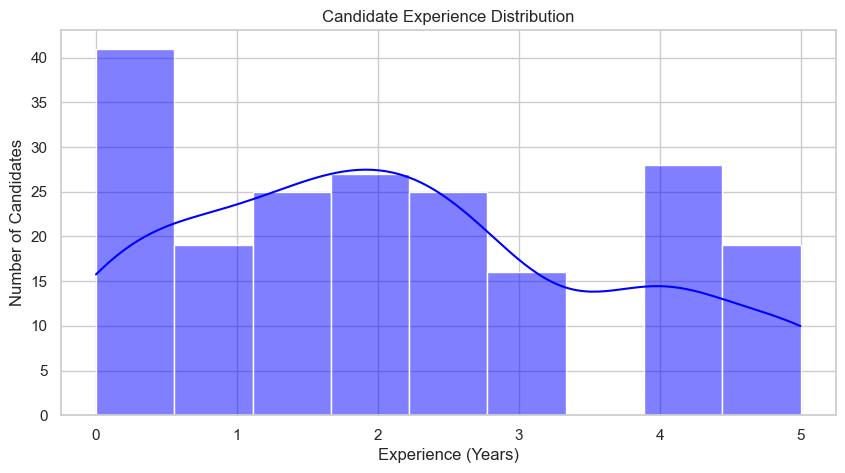

In [43]:
plt.figure(figsize=(10,5))

sns.histplot(
    pd_1["experience_years"],
    bins=9,
    kde=True,color="blue"
)

plt.title("Candidate Experience Distribution")
plt.xlabel("Experience (Years)")
plt.ylabel("Number of Candidates")


In [51]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

## Analyze candidates by location

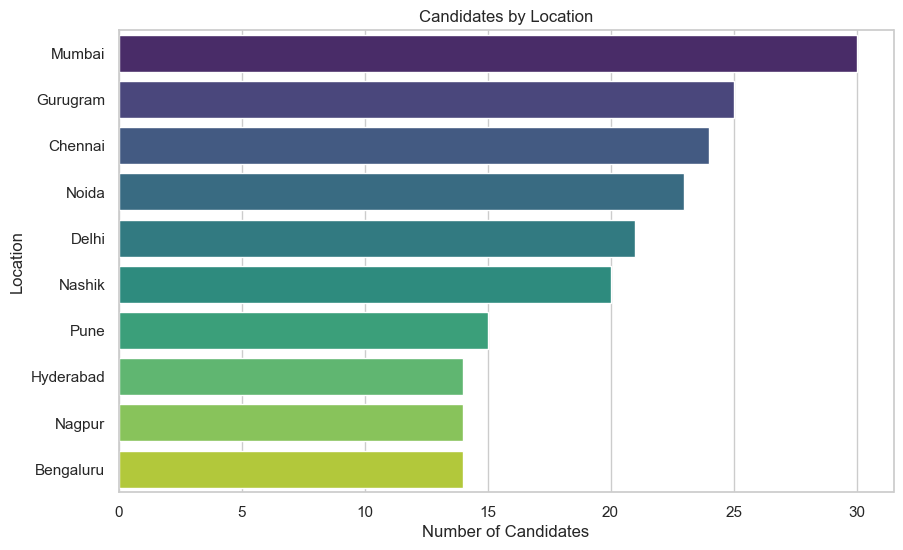

In [53]:
location_counts = pd_1["location"].value_counts()

plt.figure(figsize=(10,6))

sns.barplot(
    x=location_counts.values,
    y=location_counts.index,palette="viridis",legend=False
)

plt.title("Candidates by Location")
plt.xlabel("Number of Candidates")
plt.ylabel("Location")

plt.show()

## Analyze candidate skills

In [55]:
candidate_skill_long = (
    pd_1
    .assign(skill=pd_1["skills"].str.split(", "))
    .explode("skill")
)

In [57]:
skill_counts = candidate_skill_long["skill"].value_counts()

skill_counts

skill
Git                   74
Power BI              71
Pandas                66
JavaScript            65
Statistics            65
NumPy                 64
Java                  64
Matplotlib            63
Django                61
Flask                 61
Python                60
CSS                   60
SQL                   59
Data Visualization    58
Machine Learning      57
Excel                 57
ETL                   57
HTML                  55
AWS                   54
Tableau               48
Name: count, dtype: int64

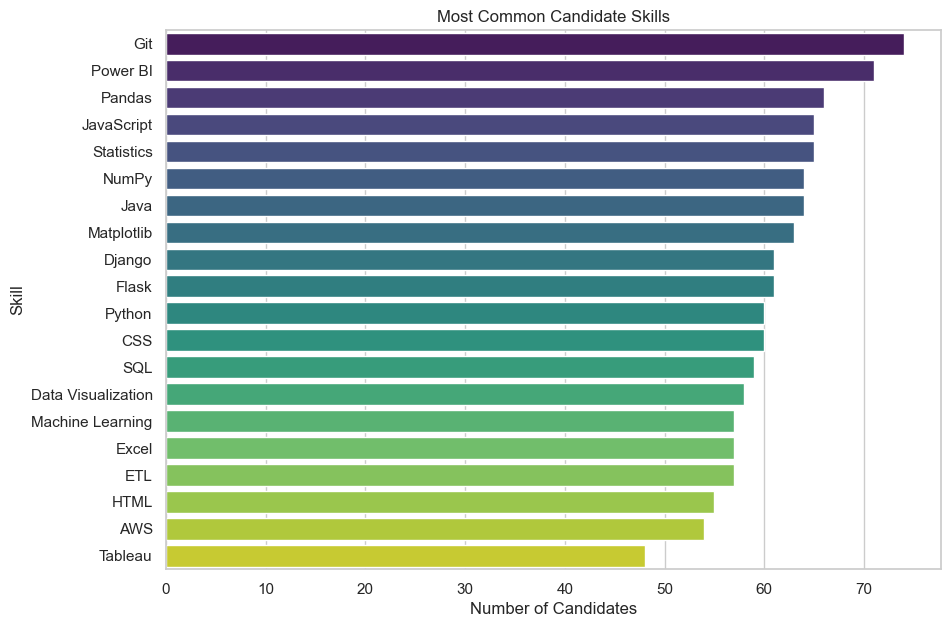

In [61]:
plt.figure(figsize=(10,7))

sns.barplot(
    x=skill_counts.values,
    y=skill_counts.index,palette="viridis"
)

plt.title("Most Common Candidate Skills")
plt.xlabel("Number of Candidates")
plt.ylabel("Skill")

plt.show()

## Analyze available jobs

In [63]:
job_title_counts = pd_2["job_title"].value_counts()

job_title_counts

job_title
BI Analyst              12
Data Analyst            11
Data Scientist          10
Python Developer         9
SQL Developer            8
ML Analyst               7
Software Developer       7
Business Analyst         6
Power BI Developer       6
Junior Data Engineer     4
Name: count, dtype: int64

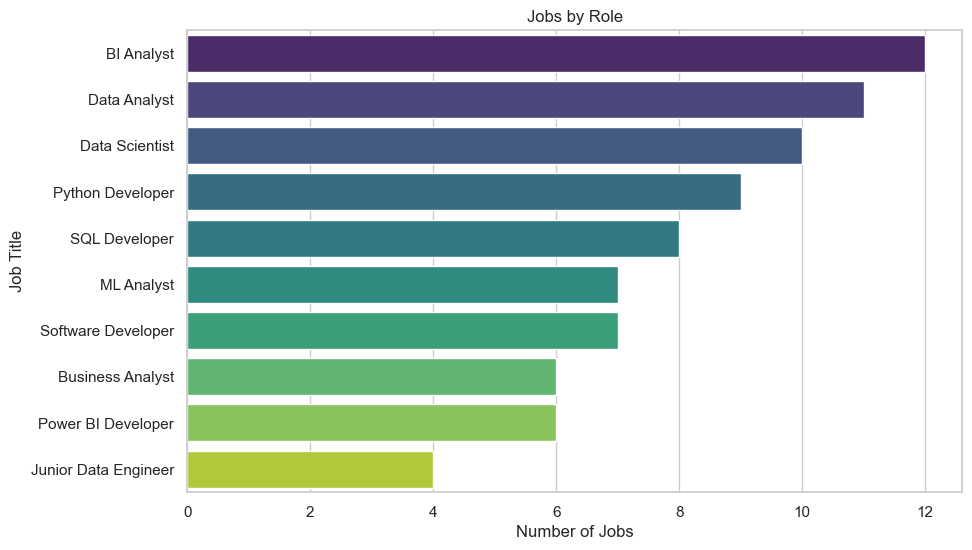

In [69]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=job_title_counts.values,
    y=job_title_counts.index,palette="viridis"
)

plt.title("Jobs by Role")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Title")

plt.show()

## Analyze salary

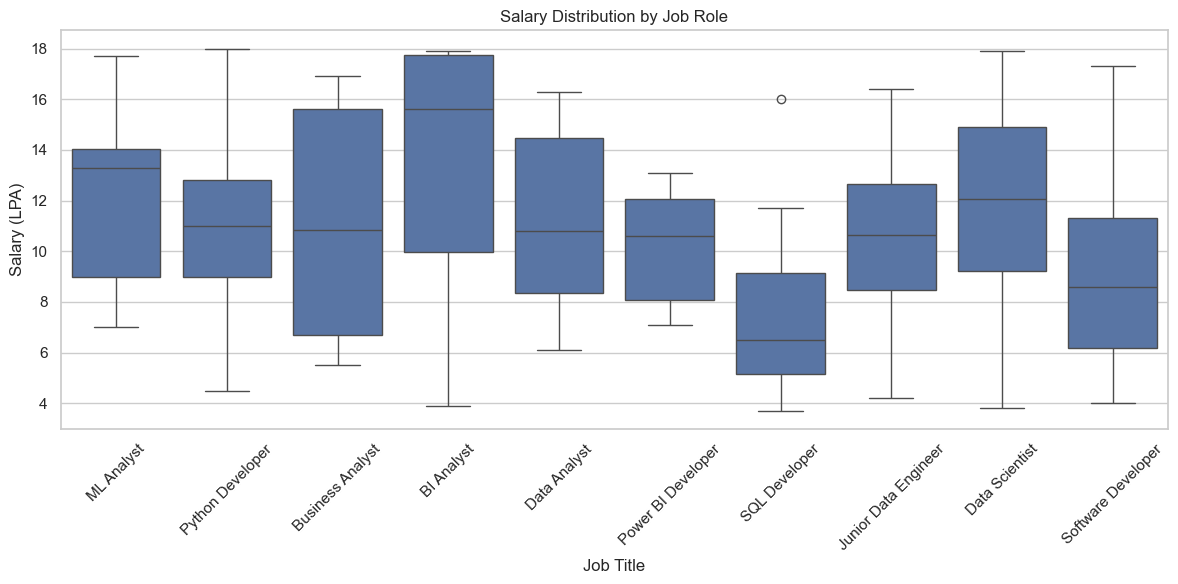

In [73]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=pd_2,
    x="job_title",
    y="salary_lpa"
)

plt.xticks(rotation=45)

plt.title("Salary Distribution by Job Role")
plt.xlabel("Job Title")
plt.ylabel("Salary (LPA)")

plt.tight_layout()
plt.show()

## Find the most demanded skills

In [75]:
job_skill_long = (
    pd_2
    .assign(skill=pd_2["required_skills"].str.split(", "))
    .explode("skill")
)

In [77]:
job_skill_counts = job_skill_long["skill"].value_counts()

job_skill_counts

skill
Machine Learning      30
Excel                 25
NumPy                 25
Flask                 24
Statistics            24
Python                23
Matplotlib            23
ETL                   23
Pandas                22
Java                  22
Power BI              21
HTML                  21
Tableau               20
Django                19
JavaScript            19
Git                   18
CSS                   18
Data Visualization    17
AWS                   16
SQL                   11
Name: count, dtype: int64

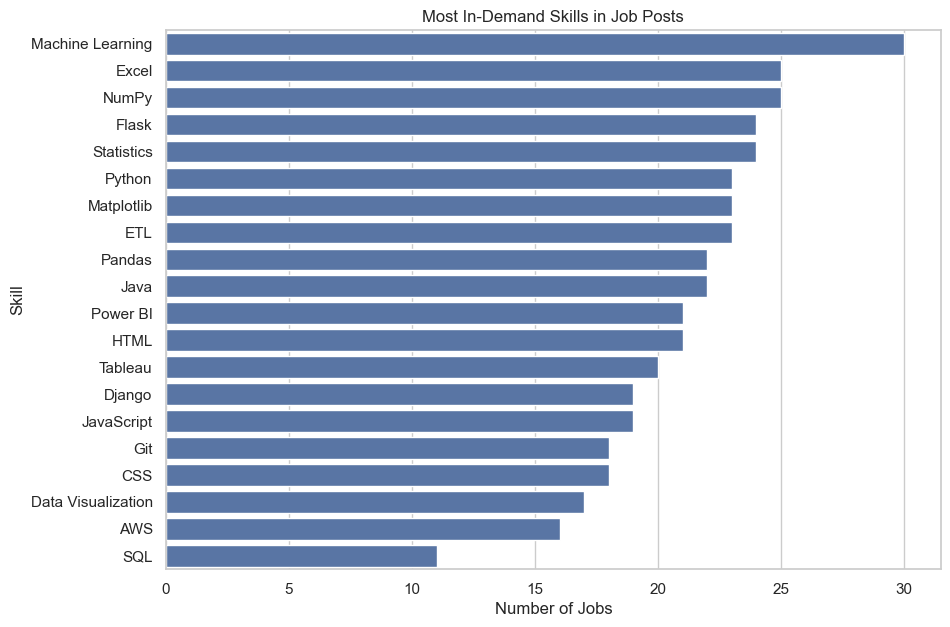

In [79]:
plt.figure(figsize=(10,7))

sns.barplot(
    x=job_skill_counts.values,
    y=job_skill_counts.index
)

plt.title("Most In-Demand Skills in Job Posts")
plt.xlabel("Number of Jobs")
plt.ylabel("Skill")

plt.show()

## Analyze job posting trends

In [81]:
pd_2["posted_month"] = pd.to_datetime(
    pd_2["posted_month"]
)

In [83]:
monthly_jobs = (
    pd_2
    .groupby("posted_month")
    .size()
    .reset_index(name="job_posts")
)

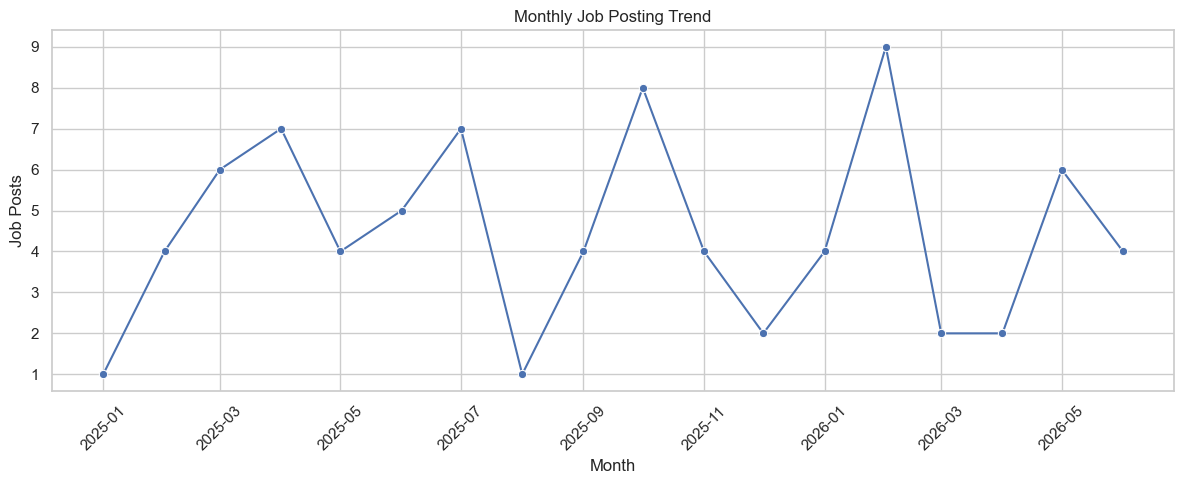

In [85]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=monthly_jobs,
    x="posted_month",
    y="job_posts",
    marker="o"
)

plt.title("Monthly Job Posting Trend")
plt.xlabel("Month")
plt.ylabel("Job Posts")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Analyze job-match scores

In [87]:
pd_3["match_score"].describe()

count    800.000000
mean      31.869238
std       19.843201
min       -5.000000
25%       19.290000
50%       30.000000
75%       45.000000
max      100.000000
Name: match_score, dtype: float64

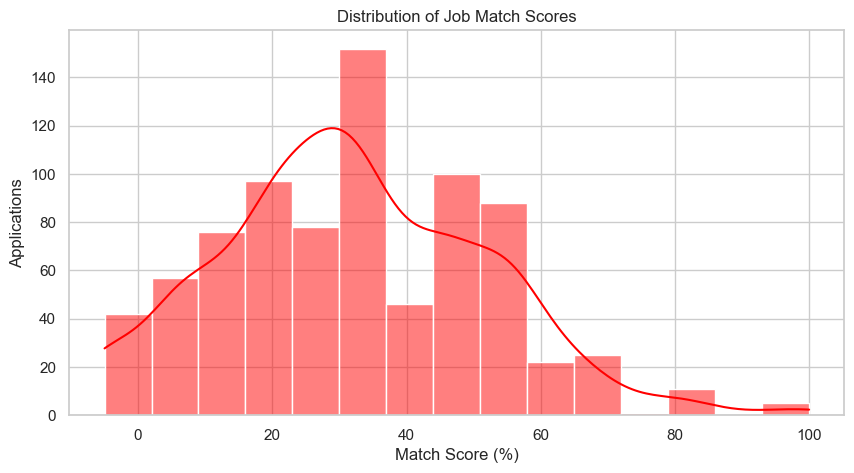

In [91]:
plt.figure(figsize=(10,5))

sns.histplot(
    pd_3["match_score"],
    bins=15,
    kde=True,color="red"
)

plt.title("Distribution of Job Match Scores")
plt.xlabel("Match Score (%)")
plt.ylabel("Applications")

plt.show()

## Analyze application status

In [93]:
pd_3["status"].value_counts()

status
Applied        308
Shortlisted    174
Interview      141
Rejected       123
Selected        54
Name: count, dtype: int64

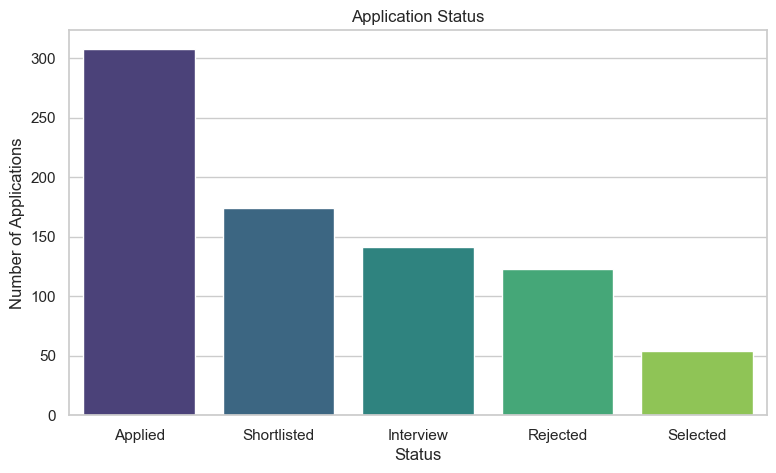

In [99]:
status_counts = pd_3["status"].value_counts()

plt.figure(figsize=(9,5))

sns.barplot(
    x=status_counts.index,
    y=status_counts.values,palette="viridis"
)

plt.title("Application Status")
plt.xlabel("Status")
plt.ylabel("Number of Applications")

plt.show()

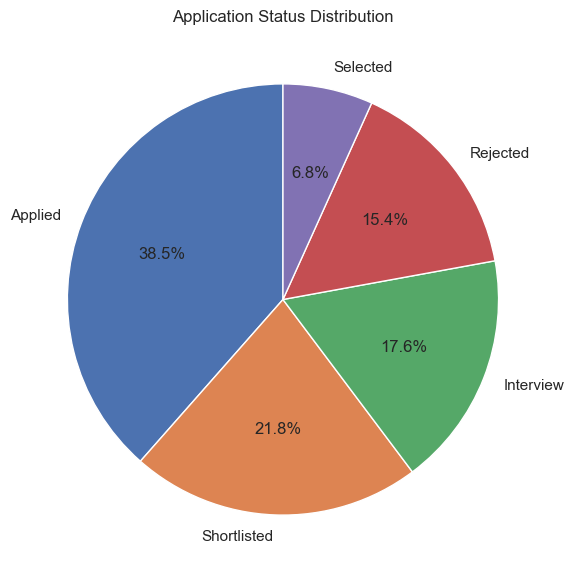

In [101]:
plt.figure(figsize=(7,7))

plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Application Status Distribution")

plt.show()

## Find average match score by status

In [103]:
avg_score = (
    pd_3
    .groupby("status")["match_score"]
    .mean()
    .sort_values(ascending=False)
)

avg_score

status
Interview      34.044326
Shortlisted    33.619483
Selected       32.601296
Applied        30.445584
Rejected       30.143415
Name: match_score, dtype: float64

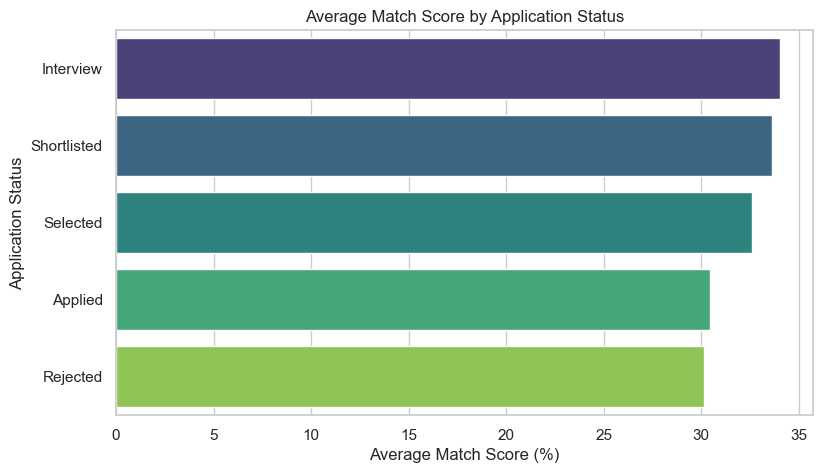

In [107]:
plt.figure(figsize=(9,5))

sns.barplot(
    x=avg_score.values,
    y=avg_score.index,palette="viridis"
)

plt.title("Average Match Score by Application Status")
plt.xlabel("Average Match Score (%)")
plt.ylabel("Application Status")

plt.show()

## Create the job matching algorithm

In [109]:
def calculate_match(candidate_skills, job_skills):

    candidate_set = {
        skill.strip().lower()
        for skill in candidate_skills
    }

    job_set = {
        skill.strip().lower()
        for skill in job_skills
    }

    matched = candidate_set.intersection(job_set)

    missing = job_set - candidate_set

    if len(job_set) > 0:
        score = len(matched) / len(job_set) * 100
    else:
        score = 0

    return round(score, 2), matched, missing

In [111]:
candidate_skills = [
    "Python",
    "SQL",
    "Power BI",
    "Excel"
]

job_skills = [
    "Python",
    "SQL",
    "Power BI",
    "Excel",
    "Tableau"
]

score, matched, missing = calculate_match(
    candidate_skills,
    job_skills
)

print("Match Score:", score, "%")
print("Matched:", matched)
print("Missing:", missing)

Match Score: 80.0 %
Matched: {'sql', 'excel', 'python', 'power bi'}
Missing: {'tableau'}
